<center>

# Analytical calculations for Incoherent test

#### Author: Daniel Lomholt Christensen

</center>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import mcstasscript as ms
import pyFAI as pf

#### Analytical form factor of sphere solution


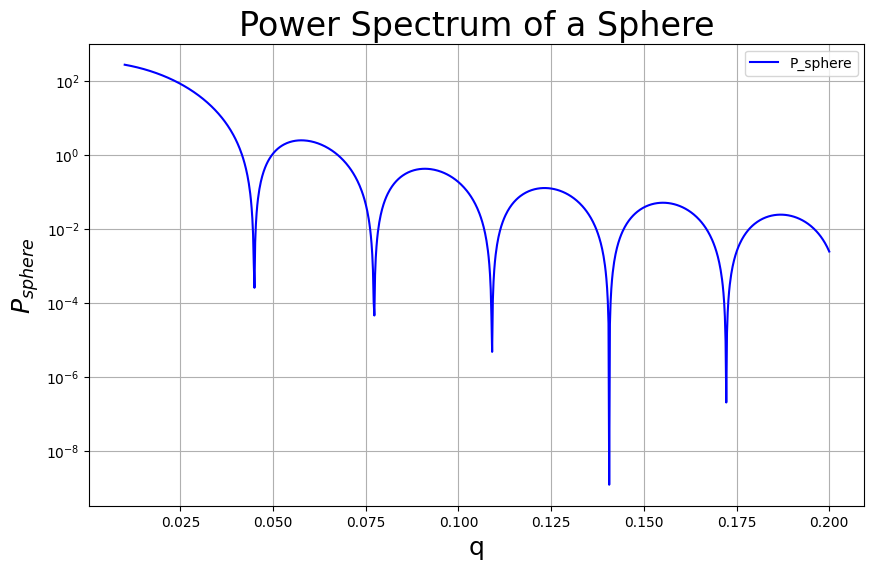

In [114]:
def P_sphere(q, R):
    res = 3*(np.sin(q*R) - q*R*np.cos(q*R) )/ (q*R)**3
    res = res**2
    return res

def n_measured(flux, A, dist, solid, sigma_att, phi,delta_rho, V, S, q,R):
    result = flux*A*dist*solid/4/np.pi*sigma_att*phi*delta_rho**2*V*S*P_sphere(q,R)
    unit_converted_result = result*10**2 # Dimension analysis yielded this factor
    return unit_converted_result
# The factor 10^8 checks out, and comes about from the femtometer in the delta rho
flux = 1e7 # n/s/cm^2
a = 1 # cm^2
dist = 1 # cm
solid = 1/25 # m^2/m^2
wavelength  = 4
v0 = 2200
v_wave = 989.0085
sigma_att = np.exp(-0.5*v0/v_wave*dist/100) # convert dist to meters
delta_rho = 5*10**-5 # Convert delta_rho from fm/AA^3 to 1/AA^2 
phi = 1e-2 #

S = 1
q = np.linspace(0.01, 0.2, 1000)
R = 100
V = 4/3*np.pi*R**3


anal = n_measured(flux, a, dist, solid, sigma_att, phi,delta_rho, V, S, q,R)

fig, ax = plt.subplots(figsize=(10,6))
ax.plot(q, anal, label='P_sphere', color='blue')
ax.set( yscale="log")
ax.set_title("Power Spectrum of a Sphere", fontsize=24)
ax.set_xlabel("q", fontsize=18)
ax.set_ylabel(r'$P_{sphere}$', fontsize=18)
ax.legend()
ax.grid(True, which='both')



In [115]:
# Load in the sans data
data = ms.load_data("../data/sans")
data = data[2] # And restrict ourselves to the last monitor

In [116]:
# detector = pf.detectors.Detector(100e-5, 100e-5)
detector = pf.detector_factory("detector")
detector.set_pixel1(1/1000)
detector.set_pixel2(1/1000)

# Set the azimuthal integrator
ai = pf.AzimuthalIntegrator(dist=5, detector=detector)


# ai = pf.integrator.azimuthal.AzimuthalIntegrator(dist=5, detector=detector)
wavelength = 1/np.sqrt(5)/0.11056
ai.set_wavelength(4*1e-10)
ai.poni1  = 0.5
ai.poni2 = 0.5
two_theta, I = ai.integrate1d(data.Intensity, 1000, unit="2th_deg") 
# result = ai.integrate2d(data.Intensity, 100)

2025-09-11 09:50:40,578 WARNING:Function AzimuthalIntegrator is deprecated since pyFAI version 0.16. Use 'pyFAI.integrator.azimuthal.AzimuthalIntegrator' instead.
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/tqv636/miniforge3/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/tqv636/miniforge3/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/tqv636/miniforge3/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/Users/tqv636/miniforge3/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 211, in start
    self.asyncio_loop.run_forever()
  File "/Users/tqv636/miniforge3/lib/python3.12/asyncio/base_events.py", line 645, in run_forever
    self._run_once()
  File "/Users/tqv636/miniforge3/lib/python3.12/asyncio/

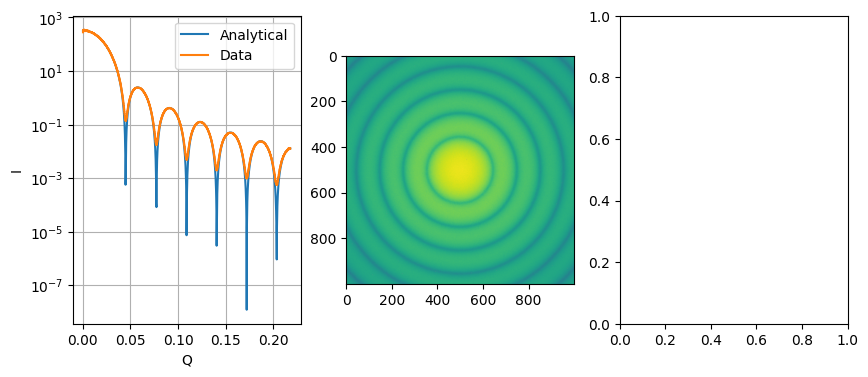

In [117]:
fig, ax = plt.subplots(ncols=3, figsize=(10,4))
q = np.sin((two_theta)*np.pi/180/2)*4*np.pi/wavelength


ax[0].set(yscale="log")

ax[0].plot(q,n_measured(flux, a, dist, solid, sigma_att, phi,delta_rho, V, S, q,R), label="Analytical")
# q = np.insert(q,0,1e-3)[:-1]
ax[0].step(q, I,label="Data")

# Set legends and labels
ax[0].legend()
ax[0].grid(True, which='major')
ax[0].set(xlabel="Q", ylabel="I")

ax[1].imshow(data.Intensity, norm="log")

# ax[2].imshow(result[0], norm="log")
